In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import regionmask
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.rcParams["figure.dpi"] = 150

# === 修改这里 ===
BASE = Path("/Users/luty8/MHW_Project/data/core/composite_result")

path_raw   = BASE / "raw_onset_resid_allvars.nc"
path_e5    = BASE / "small_onset_clusters_allvars.nc"



In [3]:
ds_raw = xr.open_dataset(path_raw)
print(ds_raw)

<xarray.Dataset> Size: 152MB
Dimensions:              (latitude: 169, longitude: 277, cluster: 4, depth: 50)
Coordinates:
  * latitude             (latitude) float32 676B 17.0 17.08 17.17 ... 30.92 31.0
  * longitude            (longitude) float32 1kB -100.0 -99.92 ... -77.08 -77.0
  * cluster              (cluster) int32 16B 0 1 2 3
  * depth                (depth) float32 200B 0.494 1.541 ... 5.728e+03
Data variables:
    bottomT_onset_resid  (cluster, latitude, longitude) float32 749kB ...
    mlotst_onset_resid   (cluster, latitude, longitude) float32 749kB ...
    so_onset_resid       (cluster, depth, latitude, longitude) float32 37MB ...
    thetao_onset_resid   (cluster, depth, latitude, longitude) float32 37MB ...
    uo_onset_resid       (cluster, depth, latitude, longitude) float32 37MB ...
    vo_onset_resid       (cluster, depth, latitude, longitude) float32 37MB ...
    zos_onset_resid      (cluster, latitude, longitude) float32 749kB ...


In [4]:
theta = ds_raw["thetao_onset_resid"]   # (cluster, depth, latitude, longitude)
depth_1d = ds_raw["depth"]             # (depth)

# 选一个 cluster 当作“有水层”的 mask
mask_valid = theta.isel(cluster=0).notnull()   # (depth, lat, lon)

# 把 depth 扩展成 3D
depth_3d = depth_1d.broadcast_like(mask_valid)  # (depth, lat, lon)

# 每个 (lat,lon) 的最大有效深度 ≈ 水深
bathy_approx = depth_3d.where(mask_valid).max("depth")  # (lat, lon)
bathy_approx.name = "bathy_approx"
bathy_approx.attrs.update(
    long_name="Approximate bottom depth from GLORYS composite",
    units="m",
)

bathy_approx

<xarray.DataArray 'bathy_approx' (latitude: 169, longitude: 277)> Size: 187kB
array([[     nan,      nan,      nan, ..., 1245.291, 1941.893, 1941.893],
       [     nan,      nan,      nan, ..., 1245.291, 1452.251, 1684.284],
       [     nan,      nan,      nan, ..., 1245.291, 1245.291, 1684.284],
       ...,
       [     nan,      nan,      nan, ..., 1941.893, 2533.336, 2533.336],
       [     nan,      nan,      nan, ..., 1941.893, 2225.078, 2533.336],
       [     nan,      nan,      nan, ..., 1941.893, 2225.078, 2533.336]],
      shape=(169, 277), dtype=float32)
Coordinates:
  * latitude   (latitude) float32 676B 17.0 17.08 17.17 ... 30.83 30.92 31.0
  * longitude  (longitude) float32 1kB -100.0 -99.92 -99.83 ... -77.08 -77.0
    cluster    int32 4B 0
Attributes:
    long_name:  Approximate bottom depth from GLORYS composite
    units:      m

In [5]:
# GLORYS 网格经纬度
lon_data = ds_raw["longitude"]
lat_data = ds_raw["latitude"]

# 你前面定义的 GoM 多边形顶点
lon_vertices = [-98, -89, -87, -84.22, -82.7, -80.5, -80.5, -83, -98, -98]
lat_vertices = [ 17.5,  17.5,  21.3,   22,   22.8,  22.9, 25.0, 30.5, 30.5, 17.0]

# 如果经度是 0–360，需要把多边形转成 0–360，这里 GLORYS 是 -100~ -80，所以不需要
if float(lon_data.max()) > 180:
    lon_vertices_360 = [(lon + 360) if lon < 0 else lon for lon in lon_vertices]
else:
    lon_vertices_360 = lon_vertices

gom_outline = np.column_stack([lon_vertices_360, lat_vertices])  # (N, 2)

gom_region = regionmask.Regions(
    [gom_outline],     # list[(N,2)]
    names=["GoM"],
    abbrevs=["GoM"],
    numbers=[0],
)

# regionmask.mask 的顺序是 (lat, lon)
mask_gom = gom_region.mask(lon_data, lat_data)  # (lat, lon)，GoM 内为 0，外为 NaN

# 转成 bool：True 表示在 GoM 内
region_gom = (mask_gom == 0)
region_gom.name = "region_gom"


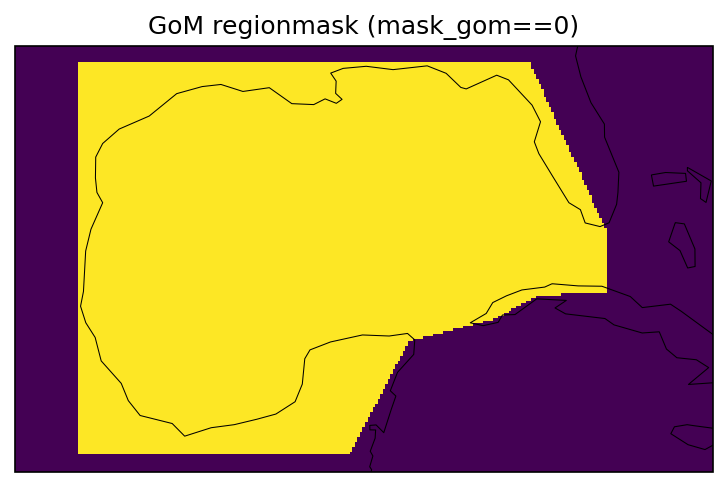

In [6]:


proj = ccrs.PlateCarree()
fig, ax = plt.subplots(subplot_kw={"projection": proj}, figsize=(6,5))

ax.coastlines(resolution="110m", linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="0.8")

pcm = ax.pcolormesh(
    lon_data,
    lat_data,
    (mask_gom == 0),     # True/False -> 1/0
    transform=proj,
    shading="auto",
)
ax.set_title("GoM regionmask (mask_gom==0)")
plt.show()

In [7]:
ds_e5 = xr.open_dataset(path_e5)
print(ds_e5)

<xarray.Dataset> Size: 8MB
Dimensions:                  (latitude: 57, longitude: 93, cluster: 4)
Coordinates:
    number                   int64 8B ...
  * latitude                 (latitude) float64 456B 31.0 30.75 ... 17.25 17.0
  * longitude                (longitude) float64 744B -100.0 -99.75 ... -77.0
  * cluster                  (cluster) int64 32B 0 1 2 3
Data variables: (12/84)
    avg_cpr_resid_mean       (cluster, latitude, longitude) float32 85kB ...
    avg_cpr_resid_t          (cluster, latitude, longitude) float32 85kB ...
    avg_cpr_resid_p          (cluster, latitude, longitude) float64 170kB ...
    avg_cpr_resid_sig05      (cluster, latitude, longitude) bool 21kB ...
    avg_iews_resid_mean      (cluster, latitude, longitude) float32 85kB ...
    avg_iews_resid_t         (cluster, latitude, longitude) float32 85kB ...
    ...                       ...
    v10_resid_p              (cluster, latitude, longitude) float64 170kB ...
    v10_resid_sig05          (cluster

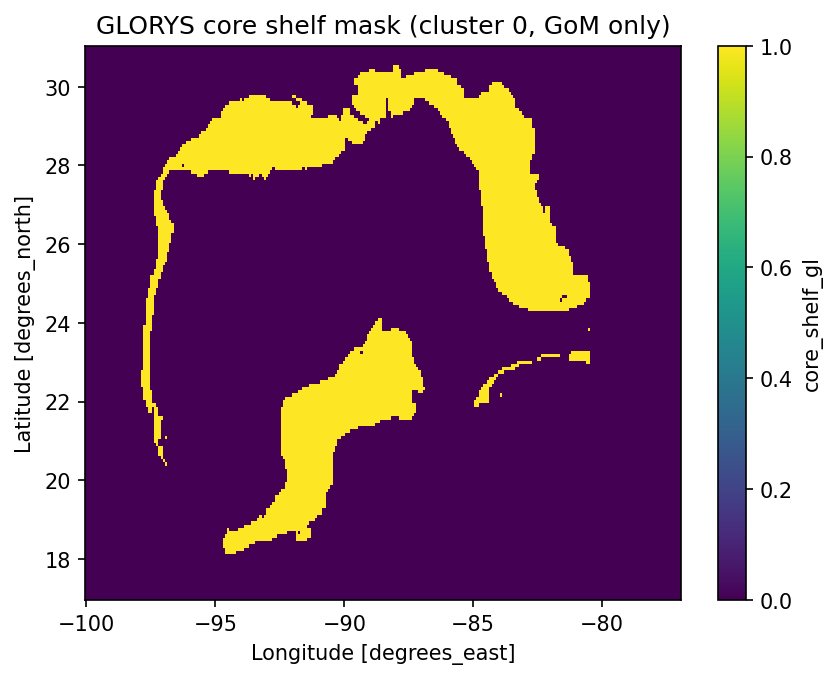

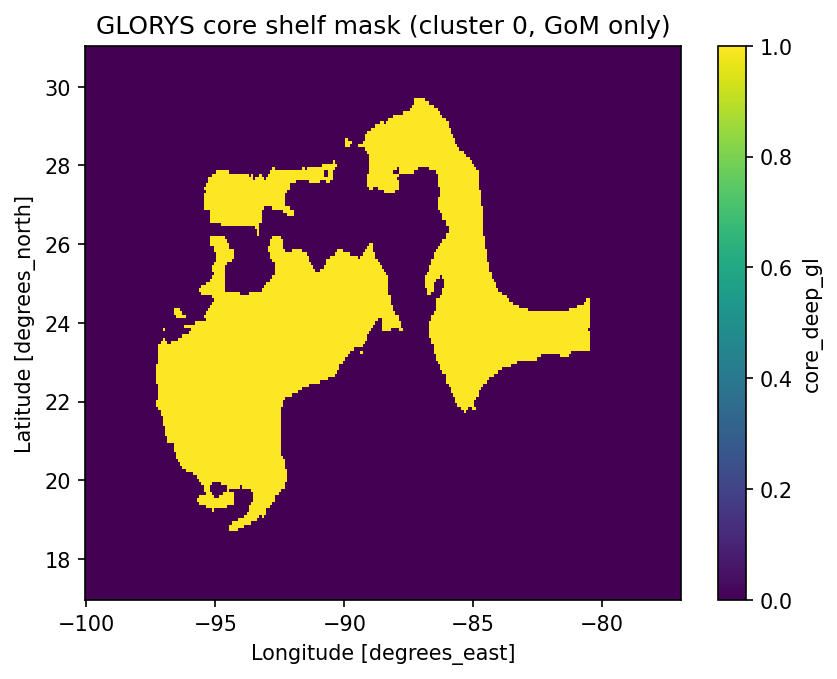

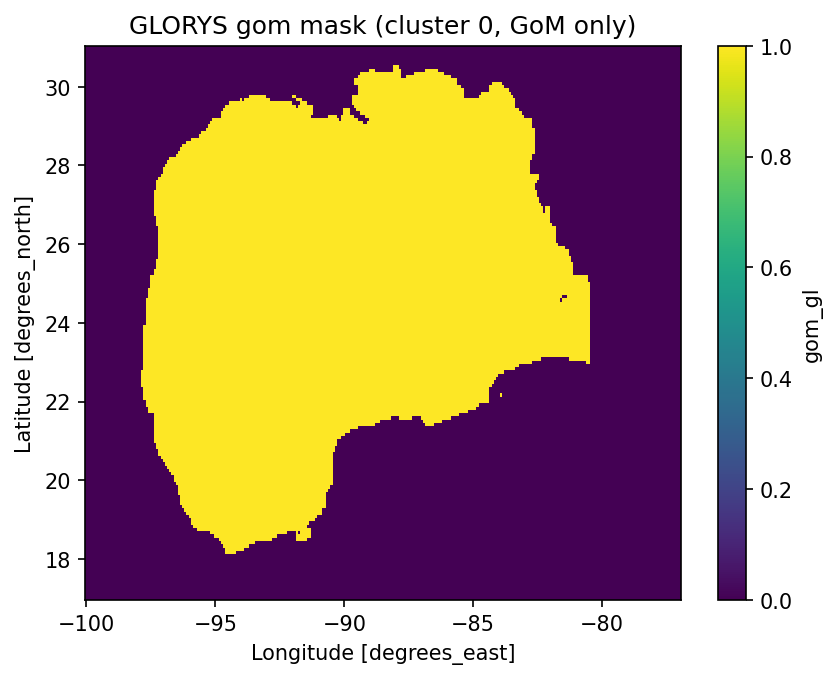

In [8]:
# 表层 θ' 当作 GLORYS 表面温度异常
theta_surf = theta.isel(depth=0)   # (cluster, lat, lon)
theta_level = 0.8  # °C

# 广播水深到 cluster 维度
bathy_bc = bathy_approx.broadcast_like(theta_surf)  # (cluster, lat, lon)

# 先按阈值+水深划分 shelf / deep
core_shelf_gl = (theta_surf > theta_level) & (bathy_bc < 200)
core_deep_gl  = (theta_surf > theta_level) & (bathy_bc >= 200)
gom_gl = (theta_surf > theta_level) & (bathy_bc > 0)
gom_gl =  (bathy_bc > 0)
# 再限制在 GoM 区域内
# region_gom 的维度是 (lat, lon)，需要广播到 cluster
region_gom_bc = region_gom.broadcast_like(theta_surf)

core_shelf_gl = core_shelf_gl & region_gom_bc
core_deep_gl  = core_deep_gl & region_gom_bc
gom_gl  = gom_gl & region_gom_bc

core_shelf_gl.name = "core_shelf_gl"
core_deep_gl.name  = "core_deep_gl"
gom_gl.name  = "gom_gl"
core_shelf_gl.isel(cluster=0).plot(x="longitude", y="latitude")
plt.title("GLORYS core shelf mask (cluster 0, GoM only)")
plt.show()
core_deep_gl.isel(cluster=0).plot(x="longitude", y="latitude")
plt.title("GLORYS core shelf mask (cluster 0, GoM only)")
plt.show()
gom_gl.isel(cluster=0).plot(x="longitude", y="latitude")
plt.title("GLORYS gom mask (cluster 0, GoM only)")
plt.show()

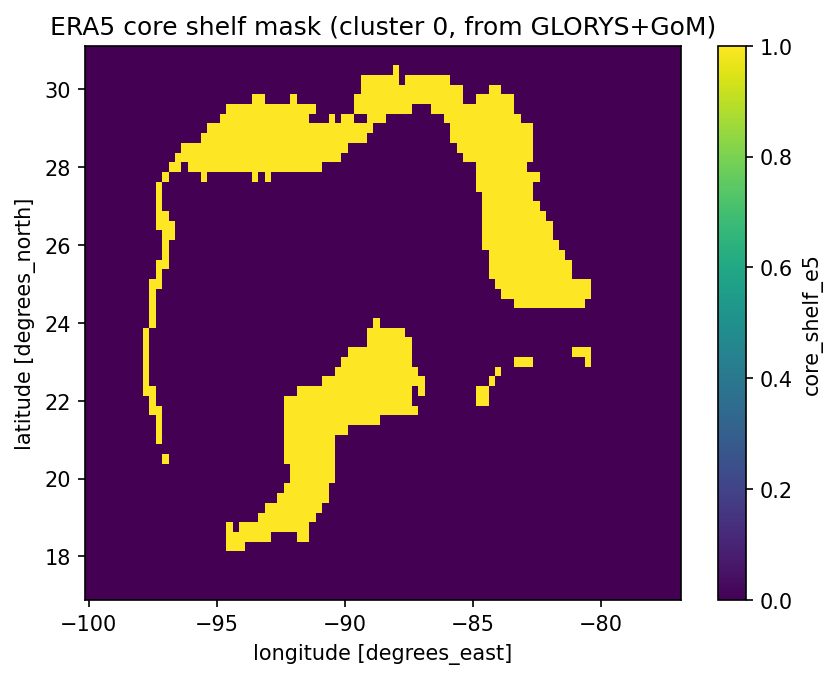

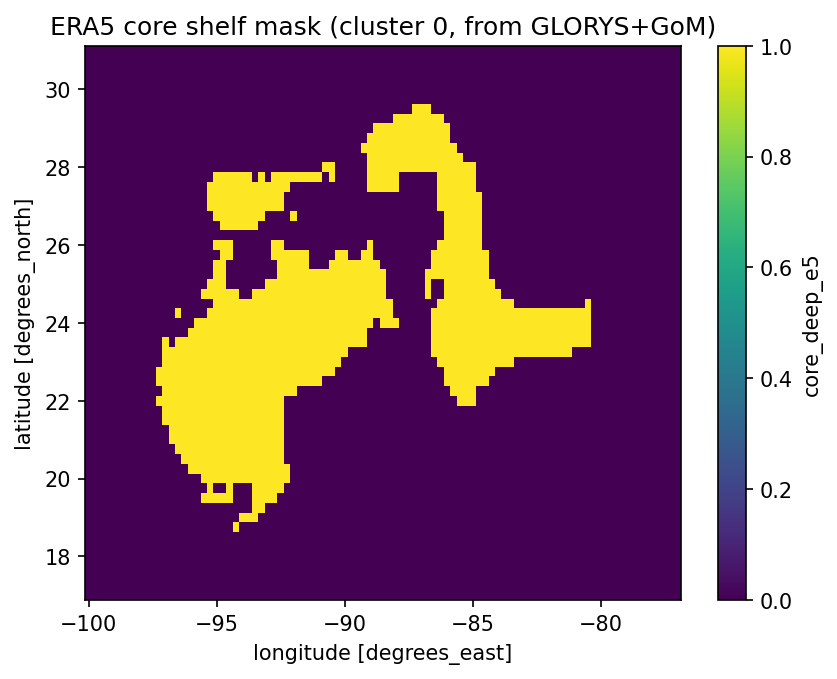

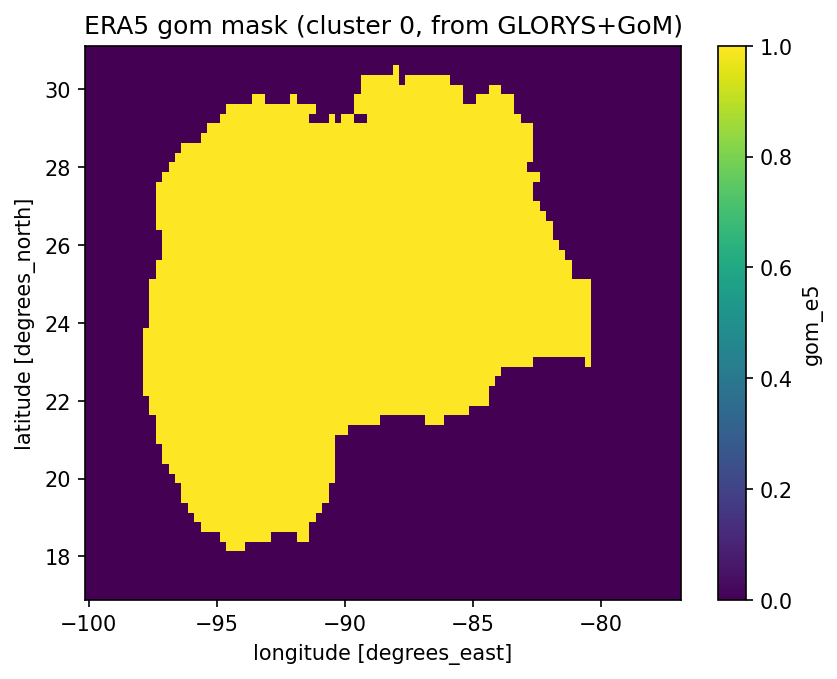

In [9]:
lat_e5 = ds_e5["latitude"]
lon_e5 = ds_e5["longitude"]

# 先转成 float 再 interp
cs_gl_float = core_shelf_gl.astype("float32")
cd_gl_float = core_deep_gl.astype("float32")
cgom_gl_float = gom_gl.astype("float32")

cs_e5_float = cs_gl_float.interp(latitude=lat_e5, longitude=lon_e5, method="nearest")
cd_e5_float = cd_gl_float.interp(latitude=lat_e5, longitude=lon_e5, method="nearest")
cgom_e5float = cgom_gl_float.interp(latitude=lat_e5, longitude=lon_e5, method="nearest")

# 再转回 bool
core_shelf_e5 = cs_e5_float > 0.5
core_deep_e5  = cd_e5_float > 0.5
gom_e5  = cgom_e5float > 0.5

core_shelf_e5.name = "core_shelf_e5"
core_deep_e5.name  = "core_deep_e5"
gom_e5.name  = "gom_e5"
core_shelf_e5.isel(cluster=0).plot(x="longitude", y="latitude")
plt.title("ERA5 core shelf mask (cluster 0, from GLORYS+GoM)")
plt.show()

core_deep_e5.isel(cluster=0).plot(x="longitude", y="latitude")
plt.title("ERA5 core shelf mask (cluster 0, from GLORYS+GoM)")
plt.show()

gom_e5.isel(cluster=0).plot(x="longitude", y="latitude")
plt.title("ERA5 gom mask (cluster 0, from GLORYS+GoM)")
plt.show()

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 这里我假设你要画：短波 (SW) 和 潜热 (LH)
# 如果你想画 LH + SH，就把 SW 换成 SH 即可
SH = ds_e5["avg_ishf_resid_mean"]   # net shortwave, downward +, anomaly
LH = ds_e5["avg_slhtf_resid_mean"]    # latent heat flux, downward +, anomaly

fields = {
    "SH' (sensible heat)": SH,
    "LH' (latent heat)": LH,
}

n_clusters = ds_e5.sizes["cluster"]
lon = ds_e5["longitude"]
lat = ds_e5["latitude"]

Lon, Lat = np.meshgrid(lon, lat)

In [11]:
def print_flux_stats(name, field, mask, clusters=[0,1,2,3]):
    """
    field : DataArray (cluster, lat, lon)
    mask  : bool DataArray (cluster, lat, lon)
    """
    print(f"\n===== {name} over masked core region =====")
    for k in clusters:
        da = field.isel(cluster=k).where(mask.isel(cluster=k))
        print(f"Cluster {k}: mean={float(da.mean()):6.2f}, "
              f"min={float(da.min()):6.2f}, max={float(da.max()):6.2f}")

# 例如：
print_flux_stats("LH (shelf)", LH, core_shelf_e5)
print_flux_stats("SH (shelf)", SH, core_shelf_e5)
print_flux_stats("LH (deep)",  LH, core_deep_e5)
print_flux_stats("SH (deep)",  SH, core_deep_e5)
print_flux_stats("LH (gom)",  LH, gom_e5)
print_flux_stats("SH (gom)",  SH, gom_e5)


===== LH (shelf) over masked core region =====
Cluster 0: mean= 43.09, min= -1.89, max= 75.96
Cluster 1: mean= 22.97, min= -3.74, max= 53.43
Cluster 2: mean= 46.94, min=  0.42, max= 75.76
Cluster 3: mean= 26.62, min=  4.20, max= 40.38

===== SH (shelf) over masked core region =====
Cluster 0: mean= 10.17, min=-10.61, max= 23.49
Cluster 1: mean=  4.30, min= -8.99, max= 12.15
Cluster 2: mean= 11.64, min=-13.05, max= 23.50
Cluster 3: mean=  5.79, min= -8.52, max=  9.70

===== LH (deep) over masked core region =====
Cluster 0: mean= 56.30, min= 20.02, max= 85.30
Cluster 1: mean=   nan, min=   nan, max=   nan
Cluster 2: mean= 55.39, min= 19.18, max= 77.69
Cluster 3: mean= 34.49, min= 21.77, max= 42.19

===== SH (deep) over masked core region =====
Cluster 0: mean= 11.40, min= -7.57, max= 23.14
Cluster 1: mean=   nan, min=   nan, max=   nan
Cluster 2: mean= 11.89, min=  3.28, max= 23.66
Cluster 3: mean=  7.23, min=  4.63, max=  9.27

===== LH (gom) over masked core region =====
Cluster 0: m

In [12]:
# 短波、长波
SW = ds_e5["avg_snswrf_resid_mean"]   # net SW, downward +
LW = ds_e5["avg_snlwrf_resid_mean"]   # net LW, downward +

# 潜热、显热（ERA5: upward +, 海洋失热）
LH_raw = ds_e5["avg_slhtf_resid_mean"]
SH_raw = ds_e5["avg_ishf_resid_mean"]

# 统一约定为：正值 = 加热海洋
LH = LH_raw
SH = SH_raw

Qnet = SW + LW + LH + SH
Qnet.name = "Qnet_resid_mean"

In [13]:
lat = ds_e5["latitude"]
weights_lat = np.cos(np.deg2rad(lat))
weights = weights_lat.broadcast_like(Qnet.isel(cluster=0))

In [14]:
def area_mean_over_mask(field, mask, weights):
    """
    field: (cluster, lat, lon)
    mask:  (cluster, lat, lon) 或 (lat, lon)
    weights: (lat, lon)
    """
    if "cluster" not in mask.dims:
        mask = mask.expand_dims({"cluster": field["cluster"]}, 0)

    w = weights * mask
    num = (field * w).sum(dim=["latitude", "longitude"])
    den = w.sum(dim=["latitude", "longitude"])
    return num / den

In [15]:
terms = {
    "SW": SW,
    "LW": LW,
    "LH": LH,
    "SH": SH,
    "Qnet": Qnet,
}

results = {}
for region, mask in [("shelf", core_shelf_e5), ("deep", core_deep_e5), ("gom", gom_e5)]:
    reg = {}
    for name, da in terms.items():
        reg[name] = area_mean_over_mask(da, mask, weights)
    results[region] = xr.Dataset(reg)

df_shelf = results["shelf"].to_dataframe()
df_deep  = results["deep"].to_dataframe()
df_gom  = results["gom"].to_dataframe()

print("Core shelf heat flux (W/m^2):")
display(df_shelf)
print("Core deep heat flux (W/m^2):")
display(df_deep)
print("Core gom heat flux (W/m^2):")
display(df_gom)

Core shelf heat flux (W/m^2):


,number,depth,SW,LW,LH,SH,Qnet
cluster,,,,,,,
0,0,0.494025,-2.517399,11.505678,42.850706,10.074068,61.913053
1,0,0.494025,7.058729,4.384764,22.547755,4.189745,38.180994
2,0,0.494025,2.641022,8.069380,46.783605,11.575500,69.069507
3,0,0.494025,3.233658,5.309448,26.568100,5.773419,40.884626


Core deep heat flux (W/m^2):


,number,depth,SW,LW,LH,SH,Qnet
cluster,,,,,,,
0,0,0.494025,5.010430,7.477696,56.074305,11.322675,79.885107
1,0,0.494025,NaN,NaN,NaN,NaN,NaN
2,0,0.494025,9.349746,4.083160,55.150428,11.806790,80.390124
3,0,0.494025,8.892076,2.473589,34.470023,7.222963,53.058652


Core gom heat flux (W/m^2):


,number,SW,LW,LH,SH,Qnet
cluster,,,,,,
0,0,1.570742,9.552354,53.329621,11.252412,75.705129
1,0,9.300734,3.529363,34.716636,5.932625,53.479359
2,0,9.506750,3.043996,46.801600,10.512739,69.865085
3,0,11.158124,1.035201,24.586833,5.107147,41.887305


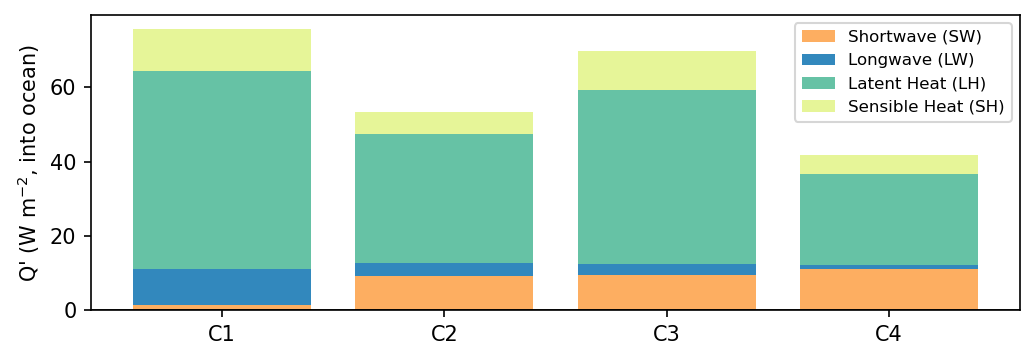

In [16]:
colors = {
    "SW": "#fdae61",
    "LW": "#3288bd",
    "LH": "#66c2a5",
    "SH": "#e6f598",
}

labels = {
    "SW": "Shortwave (SW)",
    "LW": "Longwave (LW)",
    "LH": "Latent Heat (LH)",
    "SH": "Sensible Heat (SH)",
}

def stacked_bar(df, title):
    clusters = df.index.values
    bottom = np.zeros(len(df))

    fig = plt.figure(figsize=(7,2.5))
    for term in ["SW", "LW", "LH", "SH"]:
        vals = df[term].values
        plt.bar(
            clusters, vals,
            bottom=bottom,
            label=labels[term],  # ← 全称标签
            color=colors[term],
        )
        bottom += vals

    plt.axhline(0, color="k", linewidth=0.8)
    plt.xticks(clusters, [f"C{k+1}" for k in clusters])
    plt.ylabel("Q' (W m$^{-2}$, into ocean)")
    #plt.title(title)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


#stacked_bar(df_shelf, "Core shelf: surface heat flux components'")
#stacked_bar(df_deep,  "Core deep: surface heat flux components'")
stacked_bar(df_gom,  "GoM: surface heat flux components'")


In [19]:
DPI=600
def save_fig(fig, name_base, outdir="."):
    pdf_path = f"{outdir}/{name_base}.pdf"
    png_path = f"{outdir}/{name_base}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=DPI, bbox_inches="tight")
    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")

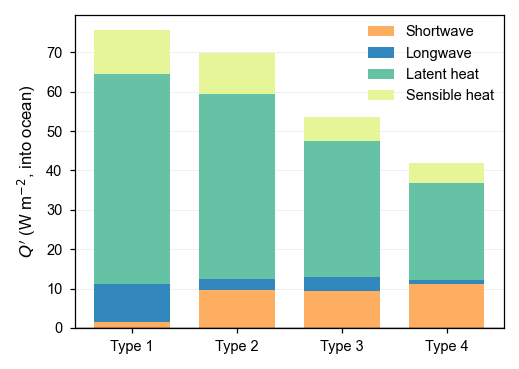

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved: /Users/luty8/Documents/TAMU/agu25/fig/Fig7_flux_bar.pdf
Saved: /Users/luty8/Documents/TAMU/agu25/fig/Fig7_flux_bar.png


In [20]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# -------------------------------------------------
# Journal-style matplotlib settings
# -------------------------------------------------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 2.3,
    "ytick.major.size": 2.3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# -------------------------------------------------
# colors and labels
# -------------------------------------------------
colors = {
    "SW": "#fdae61",
    "LW": "#3288bd",
    "LH": "#66c2a5",
    "SH": "#e6f598",
}

labels = {
    "SW": "Shortwave",
    "LW": "Longwave",
    "LH": "Latent heat",
    "SH": "Sensible heat",
}

def stacked_bar_journal(
    df,
    save_path="/Users/luty8/Documents/TAMU/agu25/heat_budget_components_journal.png",
    swap_types=True,
):
    """
    Journal-style stacked bar plot for surface heat-flux components.

    Parameters
    ----------
    df : pandas.DataFrame
        index should be cluster ids (0,1,2,3) or similar
        columns must include SW, LW, LH, SH
    swap_types : bool
        if True, swap Type 2 and Type 3 to match all previous figures
    """
    # -----------------------------
    # reorder types: 1,3,2,4 in zero-based = [0,2,1,3]
    # -----------------------------
    df_plot = df.copy()
    if swap_types and len(df_plot) == 4:
        df_plot = df_plot.iloc[[0, 2, 1, 3]]

    type_labels = [f"Type {i}" for i in range(1, len(df_plot) + 1)]
    x = np.arange(len(df_plot))
    bottom = np.zeros(len(df_plot))

    # single-column style width
    fig, ax = plt.subplots(figsize=(3.5, 2.5))

    for term in ["SW", "LW", "LH", "SH"]:
        vals = df_plot[term].values
        ax.bar(
            x,
            vals,
            bottom=bottom,
            width=0.72,
            label=labels[term],
            color=colors[term],
            edgecolor="none",
        )
        bottom += vals

    # zero line
    ax.axhline(0, color="k", linewidth=0.7)

    # axes
    ax.set_xticks(x)
    ax.set_xticklabels(type_labels)
    ax.set_ylabel(r"$Q'$ (W m$^{-2}$, into ocean)")

    # light y-grid only
    ax.grid(axis="y", linewidth=0.4, alpha=0.22)
    ax.set_axisbelow(True)



    # compact legend
    ax.legend(
        frameon=False,
        ncol=1,
        loc="upper right",
        handlelength=1.8,
        borderaxespad=0.3
    )

    plt.tight_layout()
    plt.show()

    save_fig(fig, "Fig7_flux_bar", outdir="/Users/luty8/Documents/TAMU/agu25/fig")

# use
stacked_bar_journal(df_gom)